# StatsForecast Experiments

Classical statistical baselines. This notebook intentionally runs without exogenous variables.

In [1]:
import importlib

import config as shared_config
import experiment
import experiment.config
import experiment.data
import experiment.rolling_forecast.artifacts
import experiment.rolling_forecast.executors
import experiment.rolling_forecast.executors.stats
import experiment.rolling_forecast.executors.mlforecast
import experiment.rolling_forecast.executors.neural
import experiment.rolling_forecast.runner
import experiment.rolling_forecast.runtime

importlib.reload(shared_config)
importlib.reload(experiment.config)
importlib.reload(experiment.data)
importlib.reload(experiment.rolling_forecast.artifacts)
importlib.reload(experiment.rolling_forecast.executors.stats)
importlib.reload(experiment.rolling_forecast.executors.mlforecast)
importlib.reload(experiment.rolling_forecast.executors.neural)
importlib.reload(experiment.rolling_forecast.executors)
importlib.reload(experiment.rolling_forecast.runtime)
importlib.reload(experiment.rolling_forecast.runner)
importlib.reload(experiment)

from experiment import DatasetBuilder, ModelSpec, RollingForecastRunner, RunConfig

In [2]:
prepared_dataset = DatasetBuilder.from_csv(
    csv_path=shared_config.CSV_PATH,
    unique_id=shared_config.UNIQUE_ID,
    remove_last_month=shared_config.REMOVE_LAST_MONTH,
    hist_exog=shared_config.HIST_EXOG_LIST,
    futr_exog=shared_config.FUTR_EXOG_LIST,
)



def build_run_config(*, use_hist_exog: bool, use_futr_exog: bool) -> RunConfig:
    return RunConfig(
        input_size=shared_config.INPUT_SIZE,
        horizon=shared_config.HORIZON,
        split_ratio=shared_config.SPLIT_RATIO,
        sliding_step_size=shared_config.SLIDING_STEP_SIZE,
        use_hist_exog=use_hist_exog,
        use_futr_exog=use_futr_exog,
        save_plots=shared_config.SAVE_PLOTS,
        random_seed=shared_config.RANDOM_SEED,
        early_stop_patience_epochs=shared_config.EARLY_STOP_PATIENCE_EPOCHS,
        ml_early_stopping_rounds=shared_config.ML_EARLY_STOPPING_ROUNDS,
        neural_loss_name=shared_config.NEURAL_LOSS_NAME,
        neural_loss_params=shared_config.NEURAL_LOSS_PARAMS,
        neural_checkpoint_mode=shared_config.CHECKPOINT_MODE,
        save_dir=shared_config.SAVE_DIR,
        plot_forecast=shared_config.PLOT_FORECAST,
        plot_loss=shared_config.PLOT_LOSS,
        plot_loss_name=shared_config.PLOT_LOSS_NAME,
        freq=shared_config.FREQ,
    )

USE_HIST_EXOG = False
USE_FUTR_EXOG = False
SEASON_LENGTH = 7

run_config = build_run_config(
    use_hist_exog=USE_HIST_EXOG,
    use_futr_exog=USE_FUTR_EXOG,
)
runner = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config,
)


def run_model(model_spec: ModelSpec):
    result = runner.run(model_spec)
    print(result.summary())
    print(f"rolling_raw_path: {result.rolling_raw_path}")
    return result

Seed set to 2026


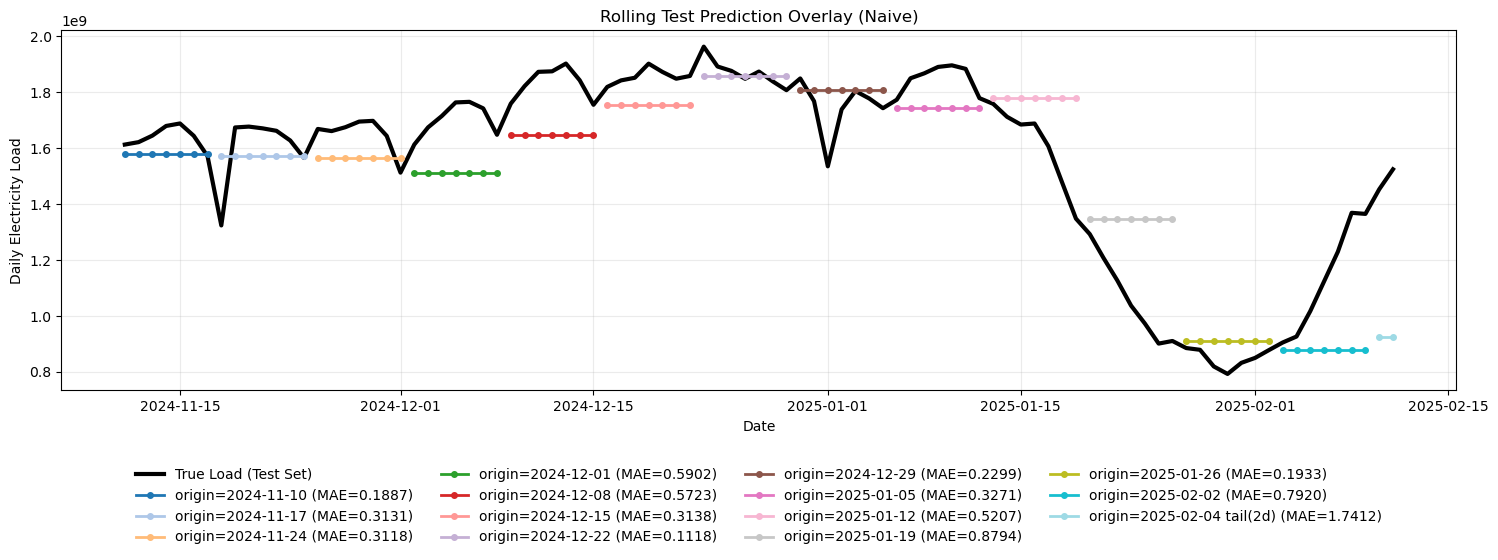

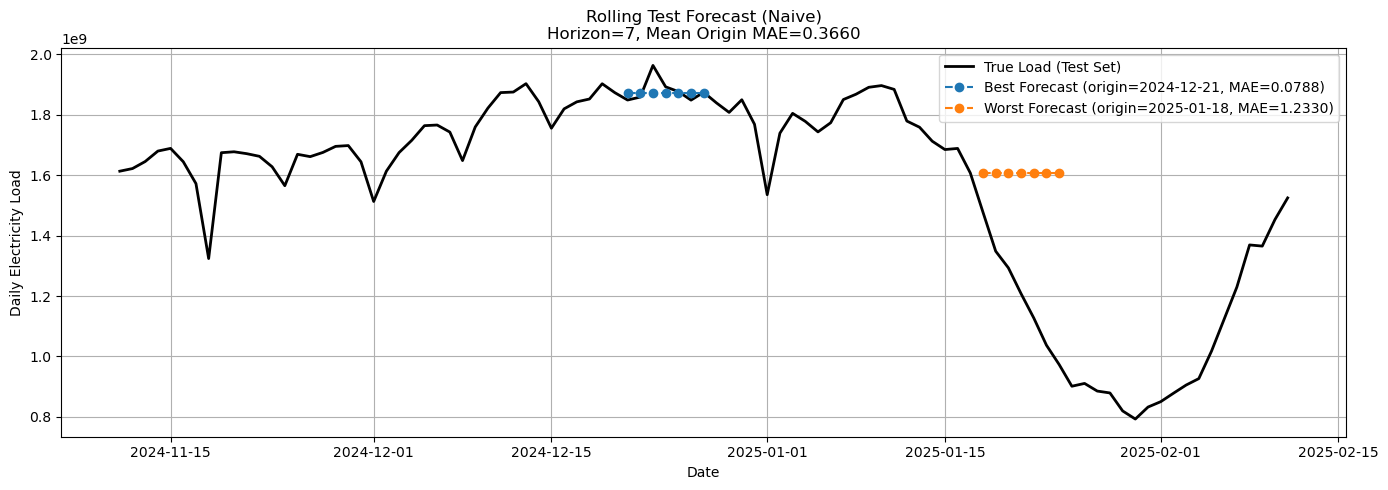

{'model_name': 'Naive', 'val_overall_mape': 7.798298665691358, 'overall_mape': 8.820472000008197, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Naive_no_feat\\20260423_212044', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\Naive_no_feat\\20260423_212044\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\Naive_no_feat\\20260423_212044\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\Naive_no_feat\20260423_212044\rolling_test_raw.csv


In [3]:
from statsforecast.models import Naive

naive_spec = ModelSpec(
    name="Naive",
    model_type="stats",
    model_cls=Naive,
    model_params={},
)

naive_result = run_model(naive_spec)

Seed set to 2026


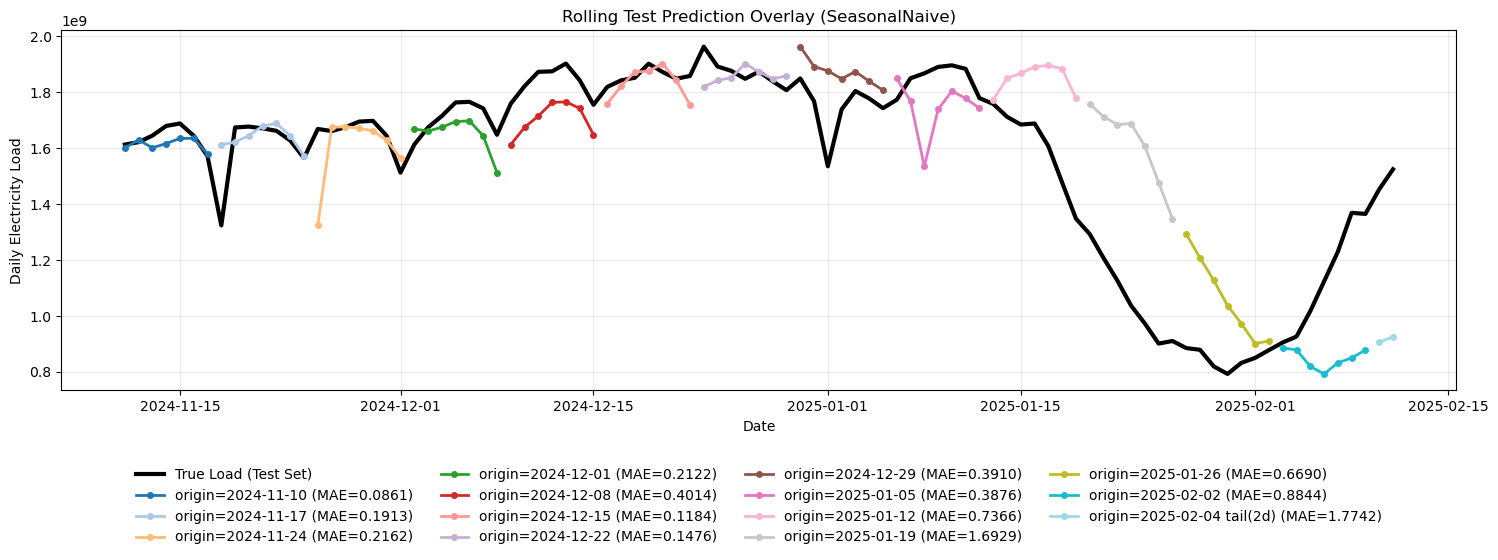

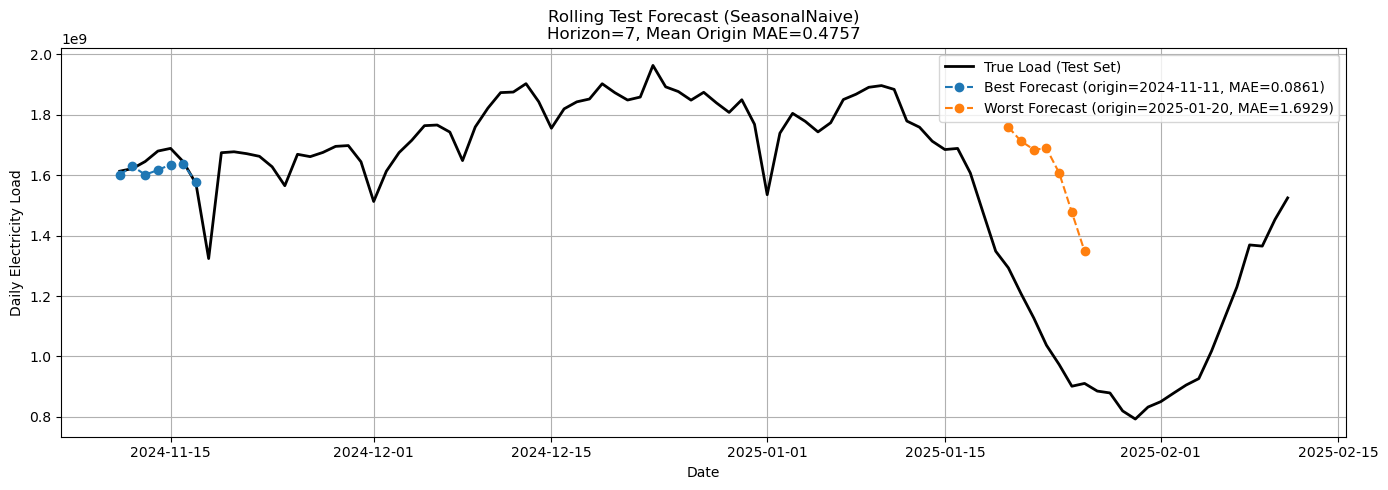

{'model_name': 'SeasonalNaive', 'val_overall_mape': 9.574693603282995, 'overall_mape': 12.180687658436582, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\SeasonalNaive_no_feat\\20260423_212046', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\SeasonalNaive_no_feat\\20260423_212046\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\SeasonalNaive_no_feat\\20260423_212046\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\SeasonalNaive_no_feat\20260423_212046\rolling_test_raw.csv


In [4]:
from statsforecast.models import SeasonalNaive

seasonalnaive_spec = ModelSpec(
    name="SeasonalNaive",
    model_type="stats",
    model_cls=SeasonalNaive,
    model_params={'season_length': SEASON_LENGTH},
)

seasonalnaive_result = run_model(seasonalnaive_spec)

Seed set to 2026


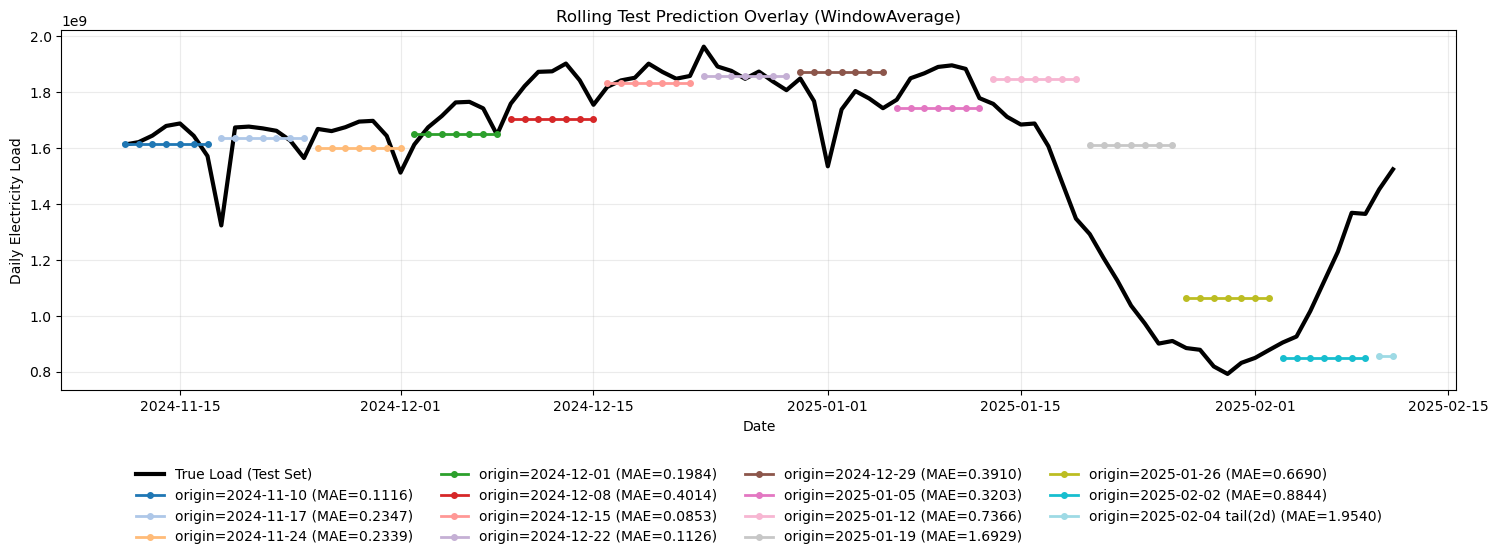

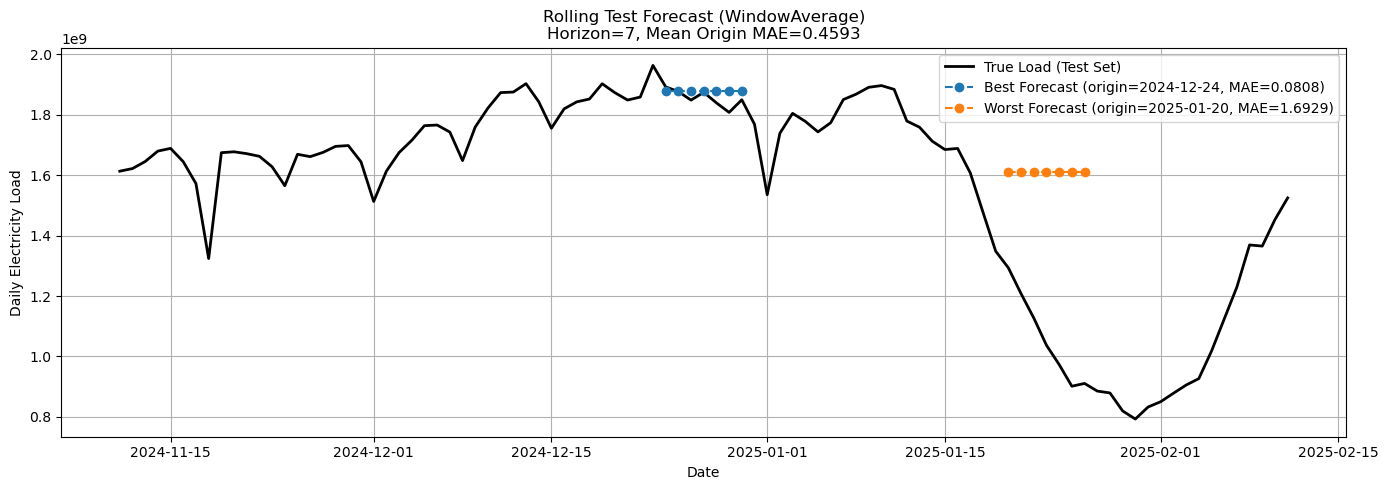

{'model_name': 'WindowAverage', 'val_overall_mape': 7.644924340136113, 'overall_mape': 11.953658428562493, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\WindowAverage_no_feat\\20260423_212048', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\WindowAverage_no_feat\\20260423_212048\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\WindowAverage_no_feat\\20260423_212048\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\WindowAverage_no_feat\20260423_212048\rolling_test_raw.csv


In [5]:
from statsforecast.models import WindowAverage

windowaverage_spec = ModelSpec(
    name="WindowAverage",
    model_type="stats",
    model_cls=WindowAverage,
    model_params={'window_size': 7},
)

windowaverage_result = run_model(windowaverage_spec)

Seed set to 2026


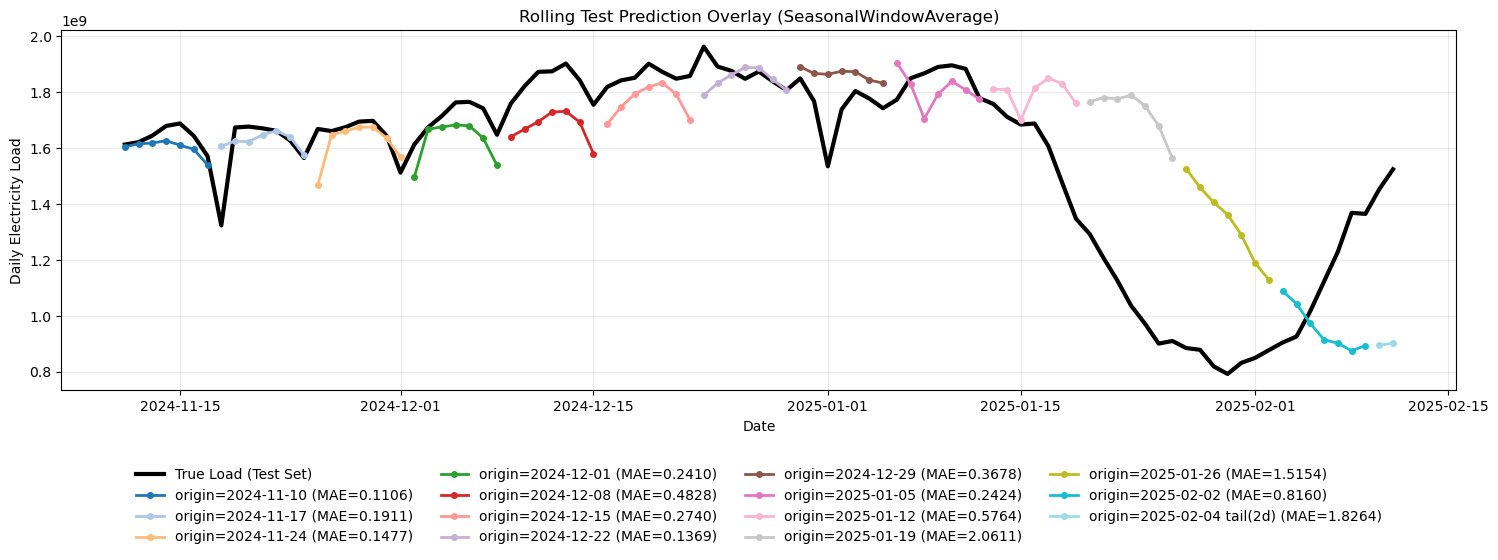

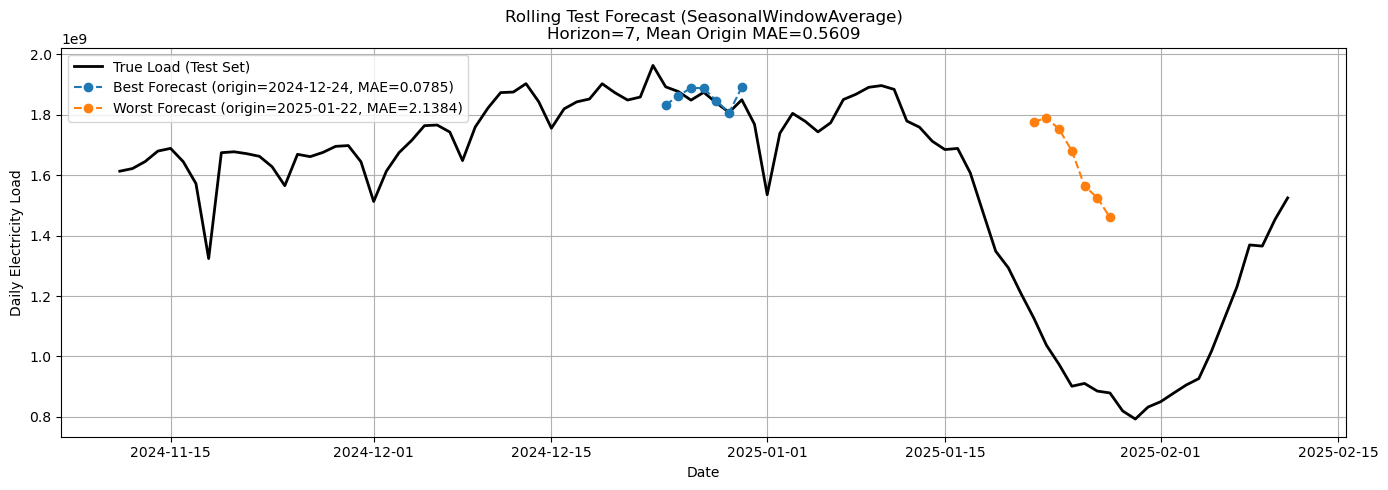

{'model_name': 'SeasonalWindowAverage', 'val_overall_mape': 9.645885414473677, 'overall_mape': 15.529968436277048, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\SeasonalWindowAverage_no_feat\\20260423_212050', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\SeasonalWindowAverage_no_feat\\20260423_212050\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\SeasonalWindowAverage_no_feat\\20260423_212050\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\SeasonalWindowAverage_no_feat\20260423_212050\rolling_test_raw.csv


In [6]:
from statsforecast.models import SeasonalWindowAverage

seasonalwindowaverage_spec = ModelSpec(
    name="SeasonalWindowAverage",
    model_type="stats",
    model_cls=SeasonalWindowAverage,
    model_params={'season_length': SEASON_LENGTH, 'window_size': 2},
)

seasonalwindowaverage_result = run_model(seasonalwindowaverage_spec)

Seed set to 2026


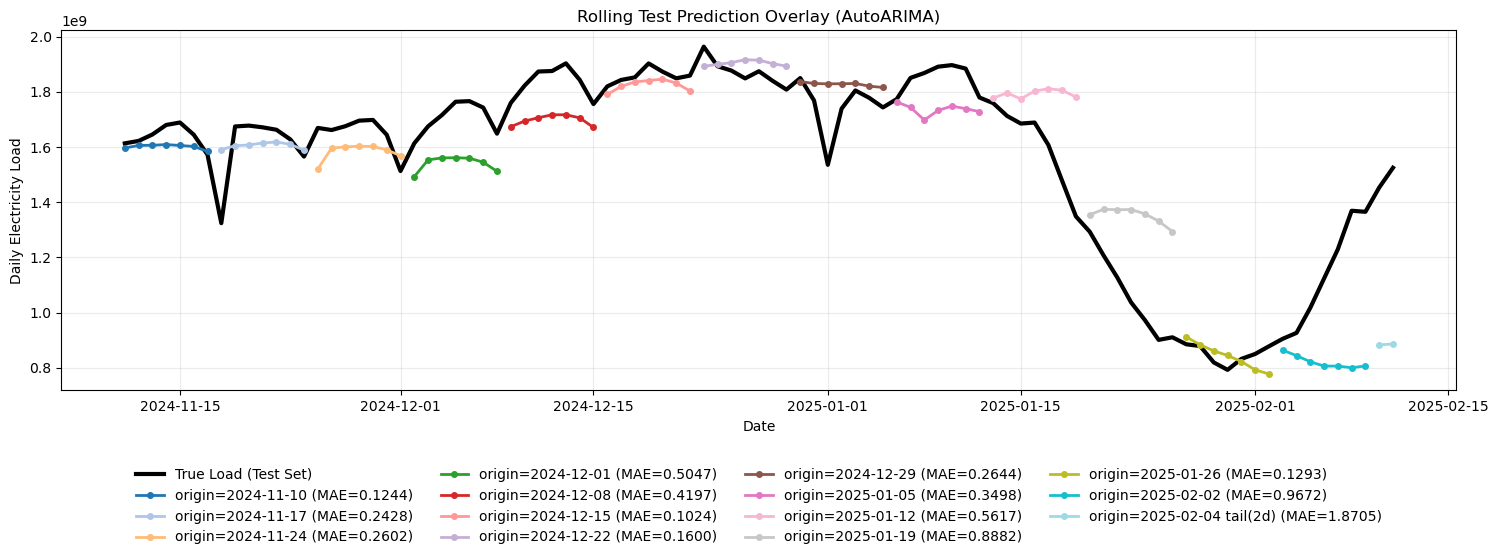

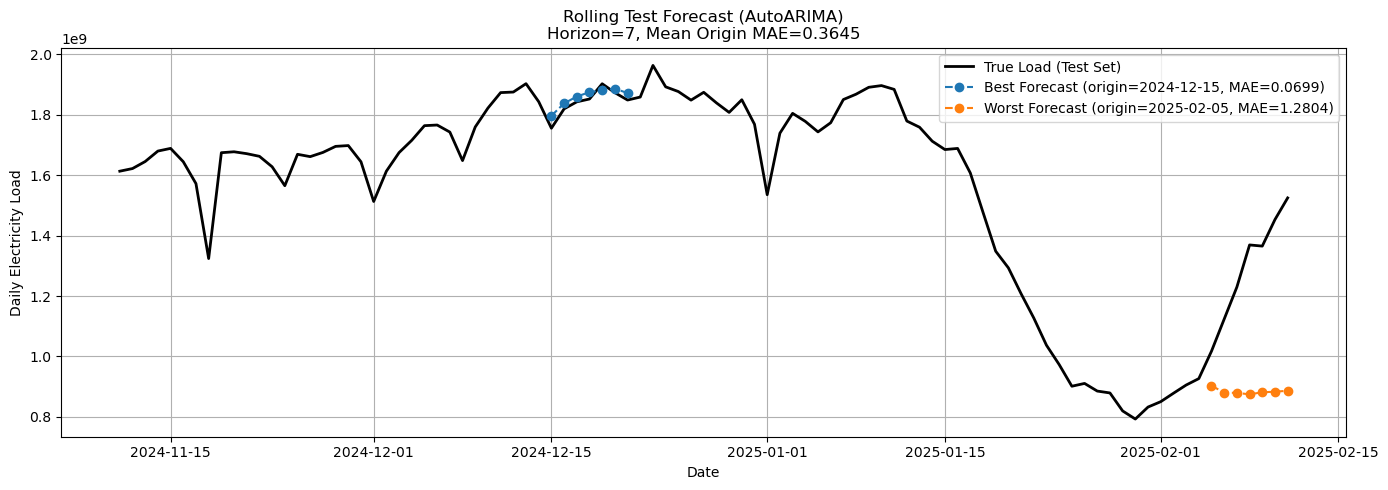

{'model_name': 'AutoARIMA', 'val_overall_mape': 8.293979903031792, 'overall_mape': 8.788257162437512, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\AutoARIMA_no_feat\\20260423_212052', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\AutoARIMA_no_feat\\20260423_212052\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\AutoARIMA_no_feat\\20260423_212052\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\AutoARIMA_no_feat\20260423_212052\rolling_test_raw.csv


In [7]:
from statsforecast.models import AutoARIMA

autoarima_spec = ModelSpec(
    name="AutoARIMA",
    model_type="stats",
    model_cls=AutoARIMA,
    model_params={'season_length': SEASON_LENGTH},
)

autoarima_result = run_model(autoarima_spec)

Seed set to 2026


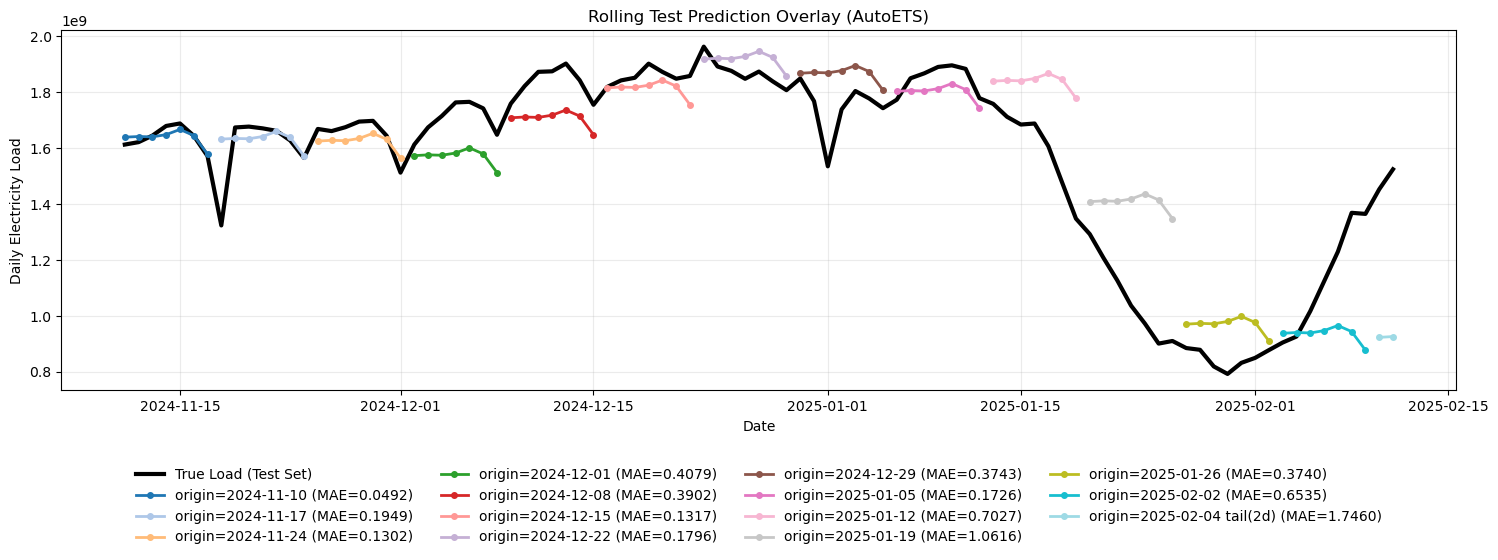

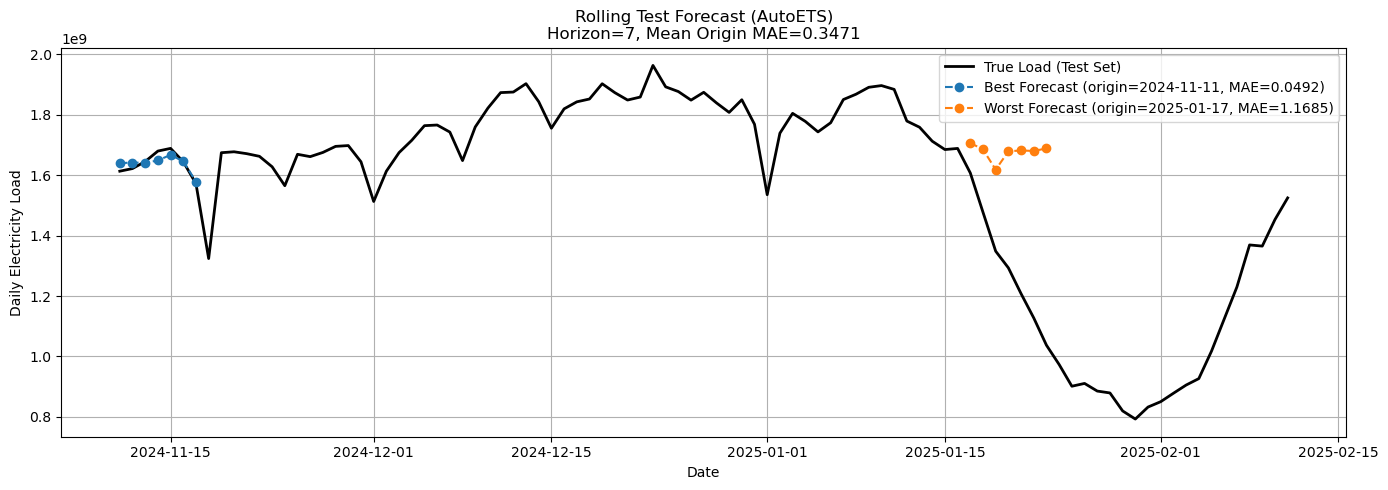

{'model_name': 'AutoETS', 'val_overall_mape': 7.583856427685125, 'overall_mape': 8.531866169178924, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\AutoETS_no_feat\\20260423_212101', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\AutoETS_no_feat\\20260423_212101\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\AutoETS_no_feat\\20260423_212101\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\AutoETS_no_feat\20260423_212101\rolling_test_raw.csv


In [8]:
from statsforecast.models import AutoETS

autoets_spec = ModelSpec(
    name="AutoETS",
    model_type="stats",
    model_cls=AutoETS,
    model_params={'season_length': SEASON_LENGTH},
)

autoets_result = run_model(autoets_spec)

Seed set to 2026


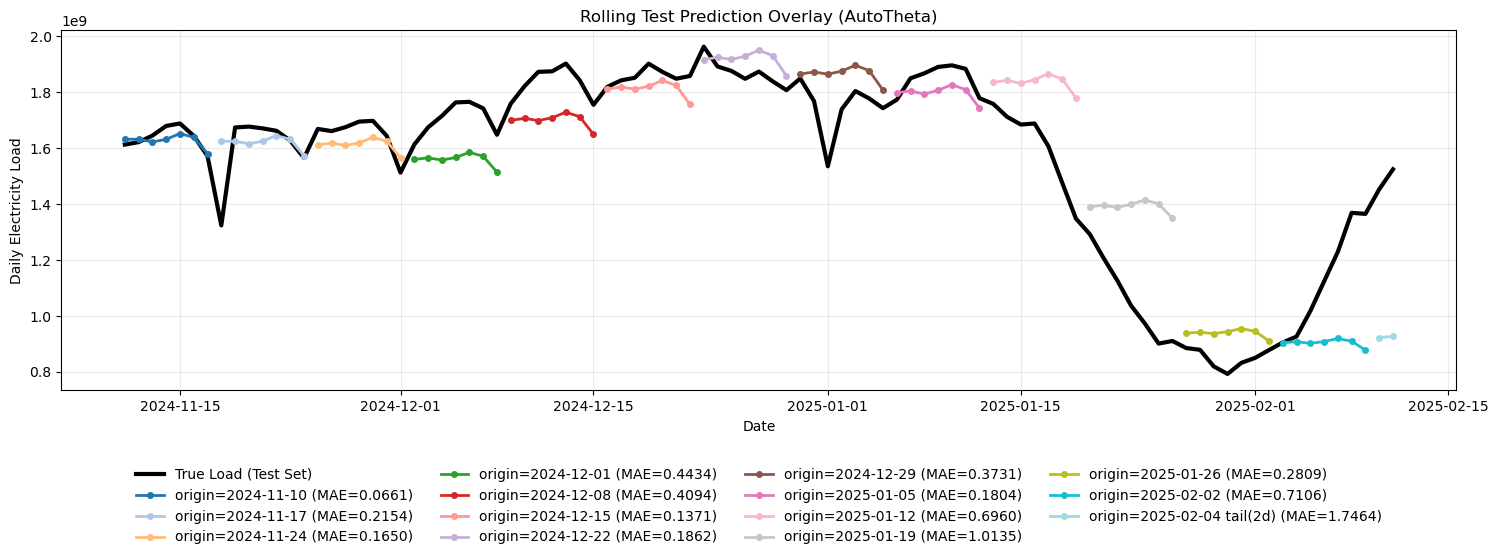

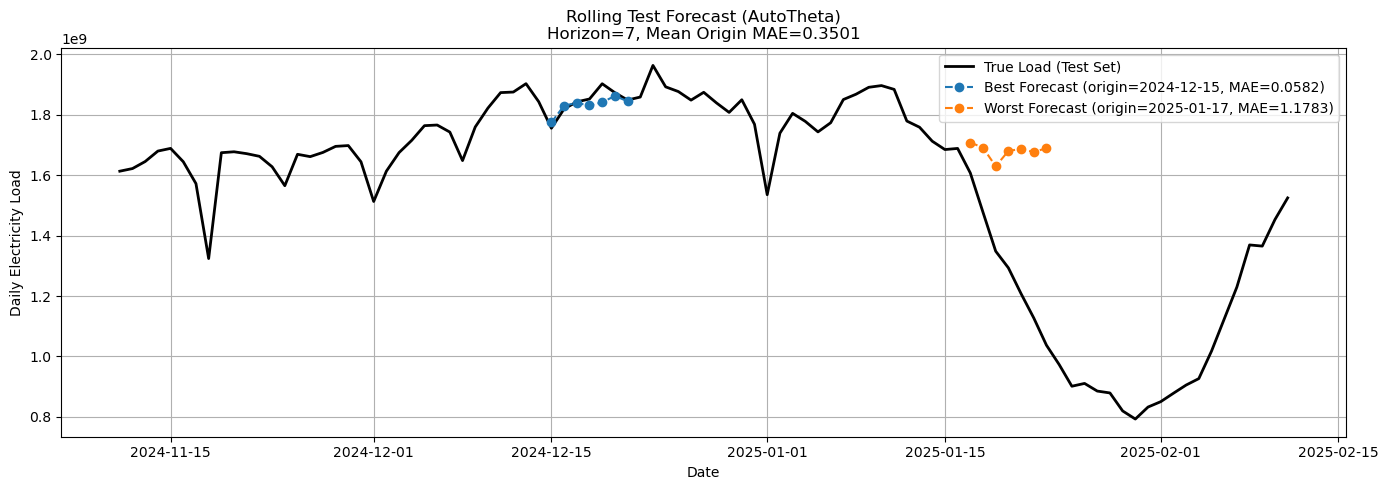

{'model_name': 'AutoTheta', 'val_overall_mape': 7.645574764032161, 'overall_mape': 8.548017630030506, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\AutoTheta_no_feat\\20260423_212104', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\AutoTheta_no_feat\\20260423_212104\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\AutoTheta_no_feat\\20260423_212104\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\AutoTheta_no_feat\20260423_212104\rolling_test_raw.csv


In [9]:
from statsforecast.models import AutoTheta

autotheta_spec = ModelSpec(
    name="AutoTheta",
    model_type="stats",
    model_cls=AutoTheta,
    model_params={'season_length': SEASON_LENGTH},
)

autotheta_result = run_model(autotheta_spec)

Seed set to 2026


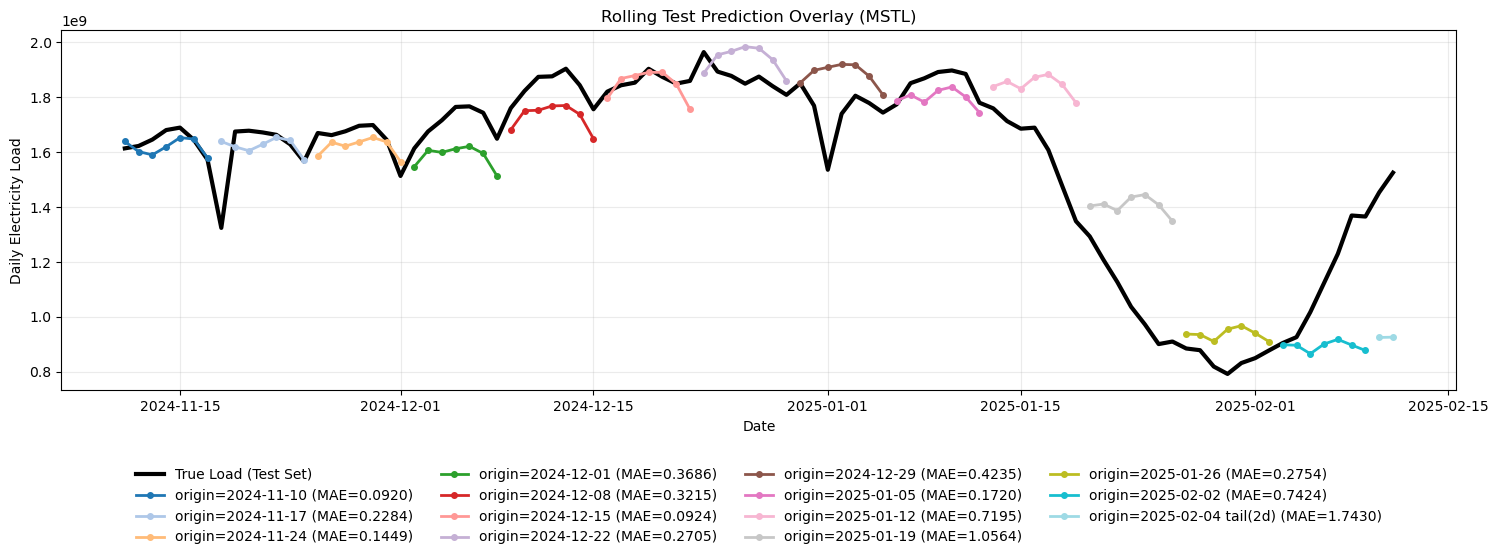

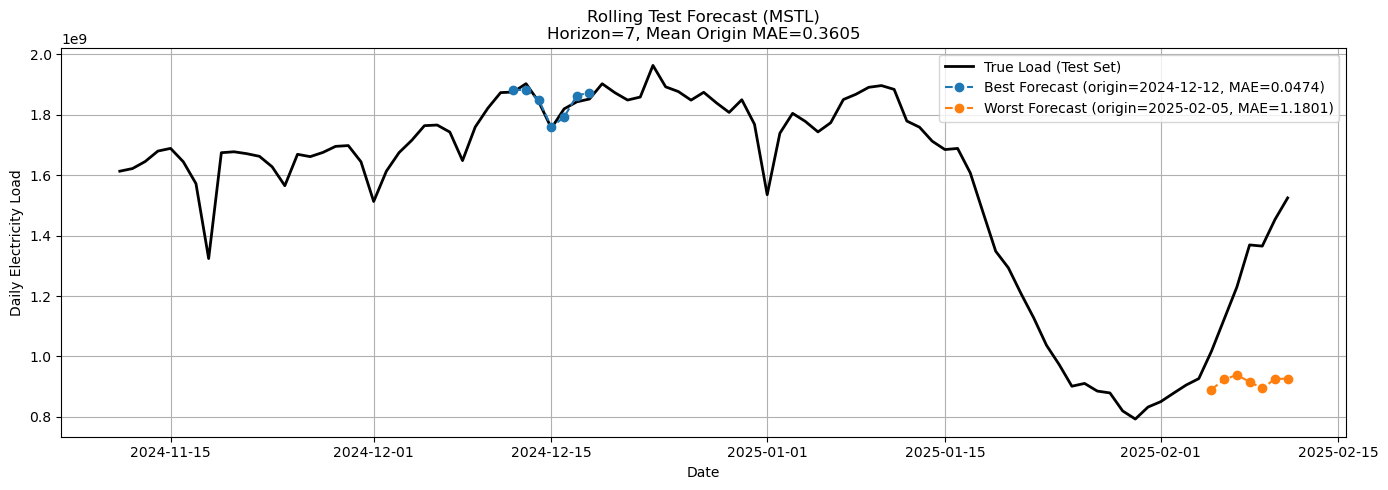

{'model_name': 'MSTL', 'val_overall_mape': 8.644457210069906, 'overall_mape': 8.778093344914295, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\MSTL_no_feat\\20260423_212106', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\MSTL_no_feat\\20260423_212106\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\MSTL_no_feat\\20260423_212106\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\MSTL_no_feat\20260423_212106\rolling_test_raw.csv


In [10]:
from statsforecast.models import MSTL

mstl_spec = ModelSpec(
    name="MSTL",
    model_type="stats",
    model_cls=MSTL,
    model_params={'season_length': SEASON_LENGTH},
)

mstl_result = run_model(mstl_spec)